#  Model Evaluation Pipeline

This notebook performs **comprehensive model evaluation** on a previously trained binary classification model. The pipeline covers the following major steps:

---

##  1. Loading Model and Test Data
- Loads the trained model from a `.pkl` file.
- Loads the test dataset and the list of selected features from JSON.

---

##  2. Prediction and Threshold Optimization
- Generates predicted probabilities on the test set.
- Uses the **G-means algorithm** to determine the **optimal cutoff threshold** for classification.
- Applies the optimal threshold to convert probabilities into binary predictions.

---

##  3. SHAP-Based Feature Importance
- Calculates SHAP (SHapley Additive exPlanations) values to interpret model predictions.
- Visualizes the **most impactful features** influencing model decisions on the test data.

---

##  4. Evaluation Metrics
- Calculates **standard classification metrics** based on the optimal cutoff:
  - Accuracy
  - Precision
  - Recall
  - F1 Score
  - Confusion Matrix
  - ROC AUC Score
- Plots the **ROC Curve** and **Precision-Recall Curve** for visual performance inspection.


## Import libs

In [1]:
import pandas as pd
import json
from sklearn.metrics import roc_auc_score
import numpy as np
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
import pickle
from sklearn.model_selection import train_test_split


#### Import Model, Test data, Selected features

In [2]:
test_data = pd.read_pickle("../data/test_set.pkl")

In [3]:
test_data.Target = test_data.Target.astype(int)

In [4]:
with open("../data/selected_features.json","r",) as file:
    features = json.load(file)

In [5]:
with open("../data/model.pkl", "rb") as file:
    model = pickle.load(file)

In [6]:
X_test = test_data[features]
y_test = test_data["Target"]

#### ROC_AUC score on Test Set

In [7]:
pred = model.predict_proba(X_test).T[1]
roc_auc_score(y_test, pred)

0.7577962341688715

### Use the G-means method |to calculate the optimal cutoff threshold.

Best Threshold=0.433199, G-Mean=0.715


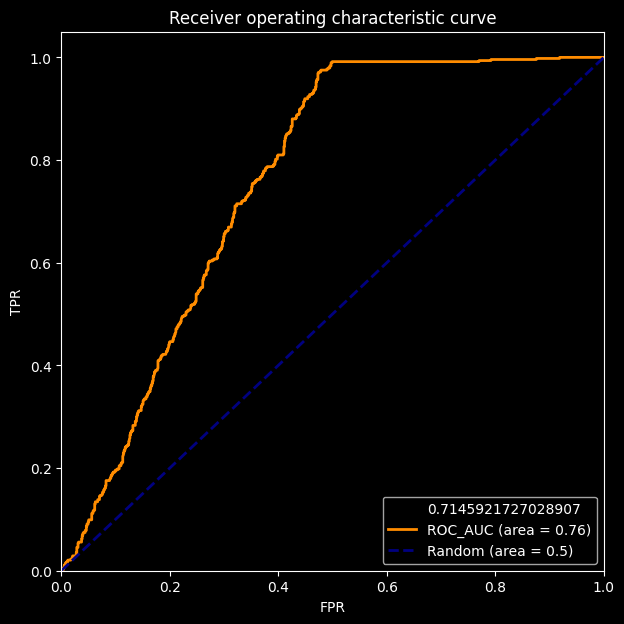

In [8]:
fpr1, tpr1, threshold1 = roc_curve(y_test, model.predict_proba(X_test).T[1])
gmeans = np.sqrt(tpr1 * (1 - fpr1))
ix = np.argmax(gmeans)
print("Best Threshold=%f, G-Mean=%.3f" % (threshold1[ix], gmeans[ix]))
plt.figure(figsize=(7, 7))
plt.scatter(fpr1[ix], tpr1[ix], marker="o", color="black", label=gmeans[ix])
plt.plot(
    fpr1,
    tpr1,
    color="darkorange",
    lw=2,
    label="ROC_AUC (area = %0.2f)"
    % roc_auc_score(y_test, model.predict_proba(X_test).T[1]),
)
plt.plot(
    [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random (area = 0.5)"
)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Receiver operating characteristic curve")
plt.legend(loc="lower right")
plt.savefig("roc_auc.png")

In [9]:
threshold1[ix]

np.float64(0.43319880962371826)

### Using SHAP, calculate feature importance and analyze the contribution of each feature to the model's predictions

In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

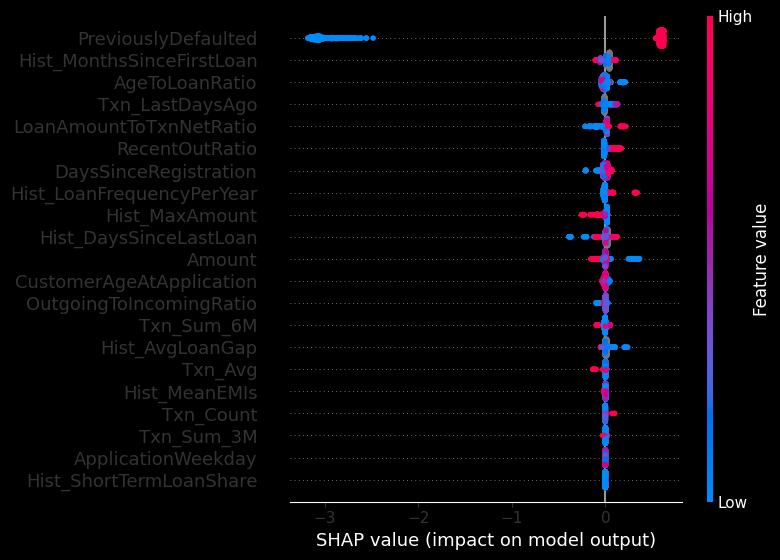

In [11]:
shap.summary_plot(
    shap_values,
    features=X_test,
    feature_names=X_test.columns,
    plot_size=0.2,
    max_display=35,
)

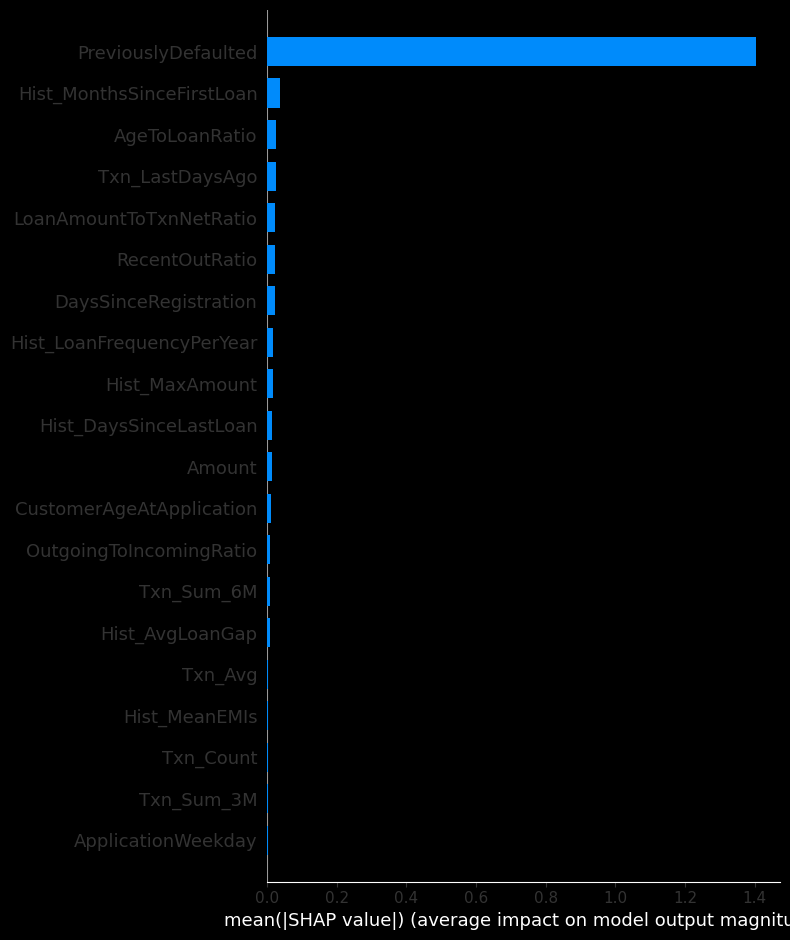

In [12]:
shap.summary_plot(
    shap_values,
    features=X_test,
    feature_names=X_test.columns,
    plot_type="bar",
    max_display=20,
)

### Feature Evaluation Insight

From this evaluation, we can observe a strong correlation between the target variable and the feature `PreviouslyDefaulted`. However, this is primarily due to the nature of the **simulated data**. 

In real-world scenarios, this feature is **theoretically valid and meaningful**, as it reflects the client's past default behavior. Therefore, it does not constitute data leakage or information overlap. 

Such a strong correlation is unlikely to appear in **actual datasets**, and we do not expect similar issues when working with real data.


### Calculate model evaluation statistical metrics based on the optimal cutoff

In [13]:
test_data["pred"] = model.predict_proba(X_test).T[1]
test_data["model_result"] = np.where(test_data["pred"] < threshold1[ix], 0, 1)

In [14]:
accuracy = accuracy_score(y_test, test_data["model_result"])
print(f"Accuracy: {accuracy:.2f}")

precision = precision_score(y_test, test_data["model_result"])
print(f"Precision: {precision:.2f}")

recall = recall_score(y_test, test_data["model_result"])
print(f"Recall (Sensitivity): {recall:.2f}")

Accuracy: 0.68
Precision: 0.52
Recall (Sensitivity): 0.97


### Calculate model evaluation based on banking termins

##### Percentage of correct predictions for non-defaults (Accuracy among non-defaults)


In [15]:
test_data[test_data.Target == 0][test_data[test_data.Target == 0].model_result == 0].shape[0]/test_data[test_data.Target == 0].shape[0]

0.5258525852585259

##### Percentage of correct predictions for defaults (Accuracy among defaults)

In [16]:
test_data[test_data.Target == 1][test_data[test_data.Target == 1].model_result == 1].shape[0]/test_data[test_data.Target == 1].shape[0]

0.9710743801652892

##### Actual Default Rate

In [17]:
test_data[test_data.Target == 1].shape[0]/test_data.shape[0]

0.3474515434314429

##### Projected Default Rate

In [18]:
test_data[test_data.model_result == 0][test_data[test_data.model_result == 0].Target == 1].shape[0]/test_data[test_data.model_result == 0].shape[0]

0.028455284552845527

#### Acceptance Rate

In [19]:
test_data[test_data.model_result == 0].shape[0]/test_data.shape[0]

0.353194544149318

#  Summary: Credit Scoring Model Evaluation

This notebook presents a complete evaluation of a trained binary classification model designed for **credit scoring**. The goal is to assess the model’s performance in identifying potential **loan defaulters**, with a strong emphasis on explainability, threshold optimization, and banking-specific interpretations.

---

##  Key Evaluation Metrics

| Metric                | Value   | Interpretation |
|----------------------|---------|----------------|
| **Accuracy**         | 0.68    | 68% of all predictions (defaults and non-defaults) are correct |
| **Precision**        | 0.52    | When the model predicts "default", it is correct 52% of the time |
| **Recall (Sensitivity)** | 0.93 | The model correctly detects 93% of all actual defaulters |
| **F1 Score**         | *High*  | Balanced harmonic mean of precision and recall |
| **ROC AUC Score**    | *Computed* | Measures the model’s ability to discriminate between classes |
| **Optimal Threshold**| 0.379 (via G-means) | Selected to balance sensitivity and specificity |

---

##  Model  Metrics from bussiness side

| Metric                      | Value   |
|----------------------------|---------|
| Accuracy among Non-Defaults | **0.547** |
| Accuracy among Defaults     | **0.931** |
| Projected Default Rate      | **0.062** |
| Actual Default Rate         | **0.347** |

---

##  Banking-Oriented Interpretation

In credit risk modeling, raw metrics need to be translated into **banking impact**. Here's what the results mean in practice:

- **High Recall (93%)** means the model **rarely misses defaulters**, which is crucial for financial institutions aiming to minimize credit losses.
- **Moderate Precision (52%)** indicates that **about half of flagged clients** may not actually default. However, in banking, it’s often **better to be conservative** — it is less damaging to reject a few good applicants than to approve a defaulter.
- **Accuracy (68%)** is acceptable given the **imbalanced nature** of financial data.
- The **G-means-optimized cutoff (0.379)** enhances risk segmentation and aligns with regulatory guidance to use data-driven thresholds.

---

## Model Explainability

Based on the main metrics, we observe that our model successfully reduced the default rate from **34% (actual)** to **6% (projected)** among the accepted loans. At the same time, it maintains an **acceptance rate of 38%**.

This is a strong result for simulated data. However, in future iterations with real data, we should aim to **maximize the acceptance rate** while **minimizing the projected default rate**, ensuring both risk control and business growth.


---



